In [9]:
from src.utils import get_data_env
from src.models import SpatialGNNModel
from src.dataloading import DeepDataLoader

disease_name    = 'chickenpox'
nuts_level      = 'nuts2'
min_date        = '2014-02-01'
max_date        = '2020-01-01'
split_trainval  = '2018-01-01'
split_valtest   = '2019-01-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 1
sequence_length = 1
lags            = 4

graphtype       = 'boolean_neighbors_self'

# training hparams
n_epochs        = 100
lr              = 0.00001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidataloader = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidataloader.add_time_features()
epidataloader.set_splits(split_trainval, split_valtest)
epidataloader.normalize()
epidata_loader_bn_logged.add_lagged_features(lags = lags)
epidataloader.finalize()


Dataloader temporal windowing: extending data collection from 2014-02-01 to 2014-01-18 (+2 weeks)


EpiDataLoader(disease=chickenpox, nuts_level=nuts2, min_date=2014-01-18, max_date=2020-01-01, horizon_size=1, horizon_leadtime=1, sequence_length=1)


==Training spatial gnn - identity_graph==
Epoch 1 train loss: 1.0123, val loss: 0.7530 ✓ (new best)
Epoch 2 train loss: 1.0062, val loss: 0.7500 ✓ (new best)
Epoch 3 train loss: 1.0019, val loss: 0.7470 ✓ (new best)
Epoch 4 train loss: 0.9971, val loss: 0.7440 ✓ (new best)
Epoch 5 train loss: 0.9927, val loss: 0.7411 ✓ (new best)
Epoch 6 train loss: 0.9884, val loss: 0.7382 ✓ (new best)
Epoch 7 train loss: 0.9836, val loss: 0.7354 ✓ (new best)
Epoch 8 train loss: 0.9792, val loss: 0.7326 ✓ (new best)
Epoch 9 train loss: 0.9762, val loss: 0.7298 ✓ (new best)
Epoch 10 train loss: 0.9701, val loss: 0.7270 ✓ (new best)
Epoch 11 train loss: 0.9669, val loss: 0.7243 ✓ (new best)
Epoch 12 train loss: 0.9621, val loss: 0.7218 ✓ (new best)
Epoch 13 train loss: 0.9599, val loss: 0.7193 ✓ (new best)
Epoch 14 train loss: 0.9549, val loss: 0.7168 ✓ (new best)
Epoch 15 train loss: 0.9517, val loss: 0.7145 ✓ (new best)
Epoch 16 train loss: 0.9465, val loss: 0.7120 ✓ (new best)
Epoch 17 train loss: 0

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 651.86it/s]

Test loss: 0.8467


NameError: name 'measles_nodes' is not defined

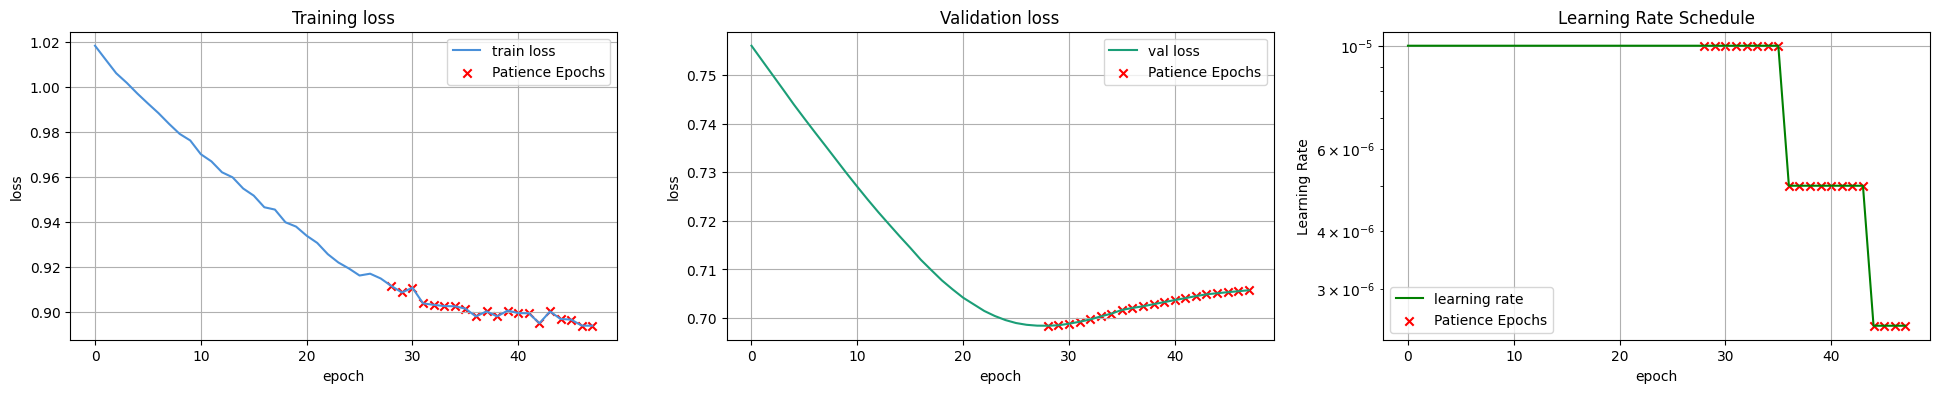

In [ ]:
graphtype = 'identity_graph'


dl1 = epidataloader.copy().retrieve_graph(graphtype).construct_dataloaders()

ml1      = SpatialGNNModel(dl1, name = f'spatial gnn - {graphtype}')
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml1.forecast('test')



==Training spatial gnn - boolean_neighbors_self==
Epoch 1 train loss: 1.0113, val loss: 0.7855 ✓ (new best)
Epoch 2 train loss: 1.0081, val loss: 0.7828 ✓ (new best)
Epoch 3 train loss: 1.0050, val loss: 0.7802 ✓ (new best)
Epoch 4 train loss: 1.0008, val loss: 0.7776 ✓ (new best)
Epoch 5 train loss: 0.9976, val loss: 0.7751 ✓ (new best)
Epoch 6 train loss: 0.9951, val loss: 0.7726 ✓ (new best)
Epoch 7 train loss: 0.9906, val loss: 0.7701 ✓ (new best)
Epoch 8 train loss: 0.9877, val loss: 0.7674 ✓ (new best)
Epoch 9 train loss: 0.9842, val loss: 0.7648 ✓ (new best)
Epoch 10 train loss: 0.9809, val loss: 0.7622 ✓ (new best)
Epoch 11 train loss: 0.9765, val loss: 0.7595 ✓ (new best)
Epoch 12 train loss: 0.9726, val loss: 0.7567 ✓ (new best)
Epoch 13 train loss: 0.9692, val loss: 0.7539 ✓ (new best)
Epoch 14 train loss: 0.9663, val loss: 0.7512 ✓ (new best)
Epoch 15 train loss: 0.9628, val loss: 0.7484 ✓ (new best)
Epoch 16 train loss: 0.9574, val loss: 0.7457 ✓ (new best)
Epoch 17 train

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 643.20it/s]

Test loss: 0.8491


SpatialGNNModel(name='spatial gnn - boolean_neighbors_self')

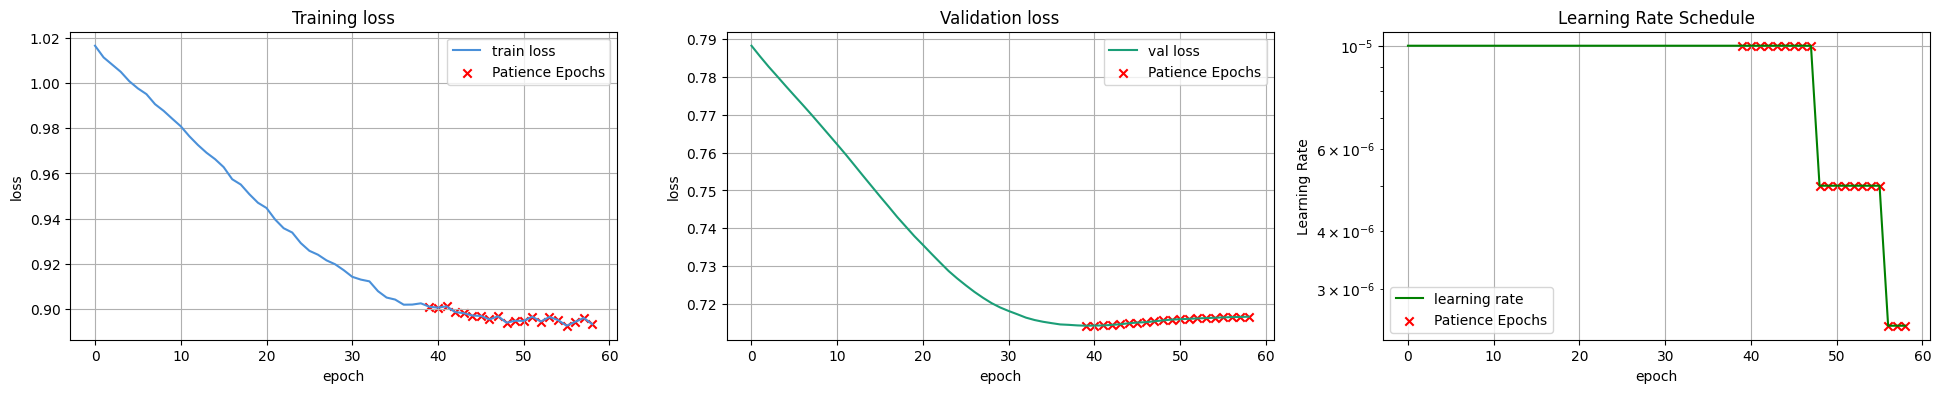

In [ ]:
graphtype = 'boolean_neighbors_self'


dl1 = epidataloader.copy().retrieve_graph(graphtype).construct_dataloaders()

ml1      = SpatialGNNModel(dl1, name = f'spatial gnn - {graphtype}')
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml1.forecast('test')
ml1.show_forecasts('test')


==  Training spatial gnn - gravity1   ==
Epoch 1 train loss: 1.0017, val loss: 0.7773 ✓ (new best)
Epoch 2 train loss: 0.9973, val loss: 0.7746 ✓ (new best)
Epoch 3 train loss: 0.9948, val loss: 0.7720 ✓ (new best)
Epoch 4 train loss: 0.9916, val loss: 0.7696 ✓ (new best)
Epoch 5 train loss: 0.9883, val loss: 0.7672 ✓ (new best)
Epoch 6 train loss: 0.9829, val loss: 0.7648 ✓ (new best)
Epoch 7 train loss: 0.9790, val loss: 0.7624 ✓ (new best)
Epoch 8 train loss: 0.9737, val loss: 0.7601 ✓ (new best)
Epoch 9 train loss: 0.9713, val loss: 0.7576 ✓ (new best)
Epoch 10 train loss: 0.9662, val loss: 0.7552 ✓ (new best)
Epoch 11 train loss: 0.9637, val loss: 0.7528 ✓ (new best)
Epoch 12 train loss: 0.9594, val loss: 0.7504 ✓ (new best)
Epoch 13 train loss: 0.9547, val loss: 0.7481 ✓ (new best)
Epoch 14 train loss: 0.9521, val loss: 0.7458 ✓ (new best)
Epoch 15 train loss: 0.9471, val loss: 0.7434 ✓ (new best)
Epoch 16 train loss: 0.9432, val loss: 0.7411 ✓ (new best)
Epoch 17 train loss: 0.

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 661.65it/s]

Test loss: 0.8464


(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'Predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

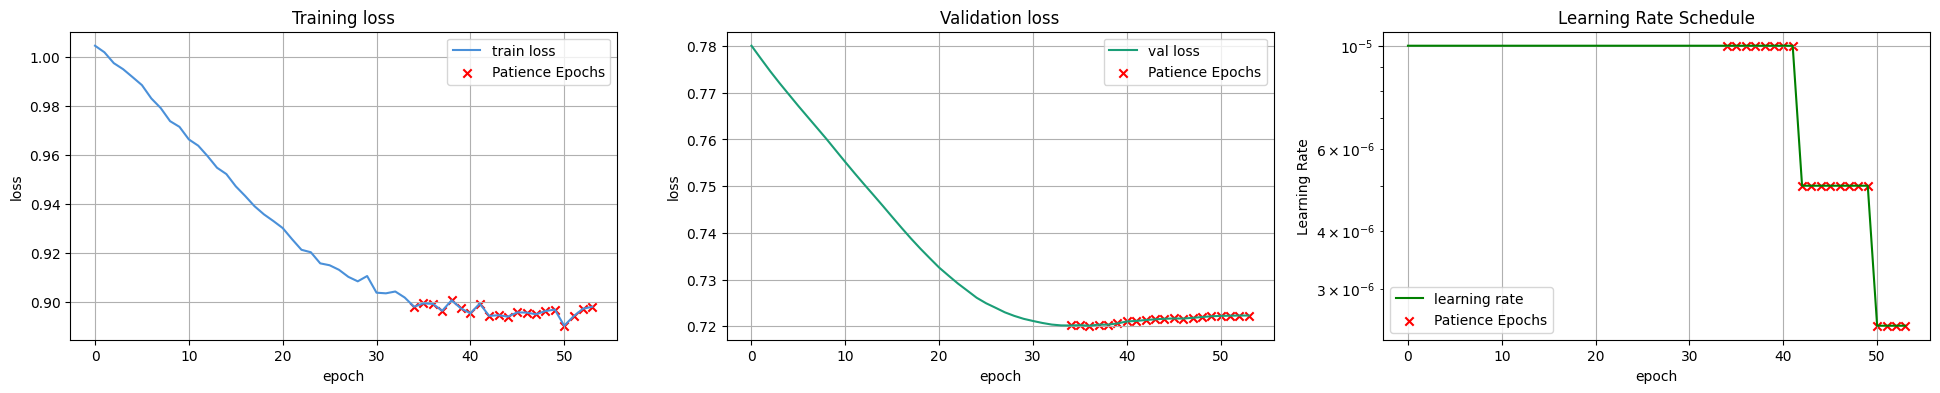

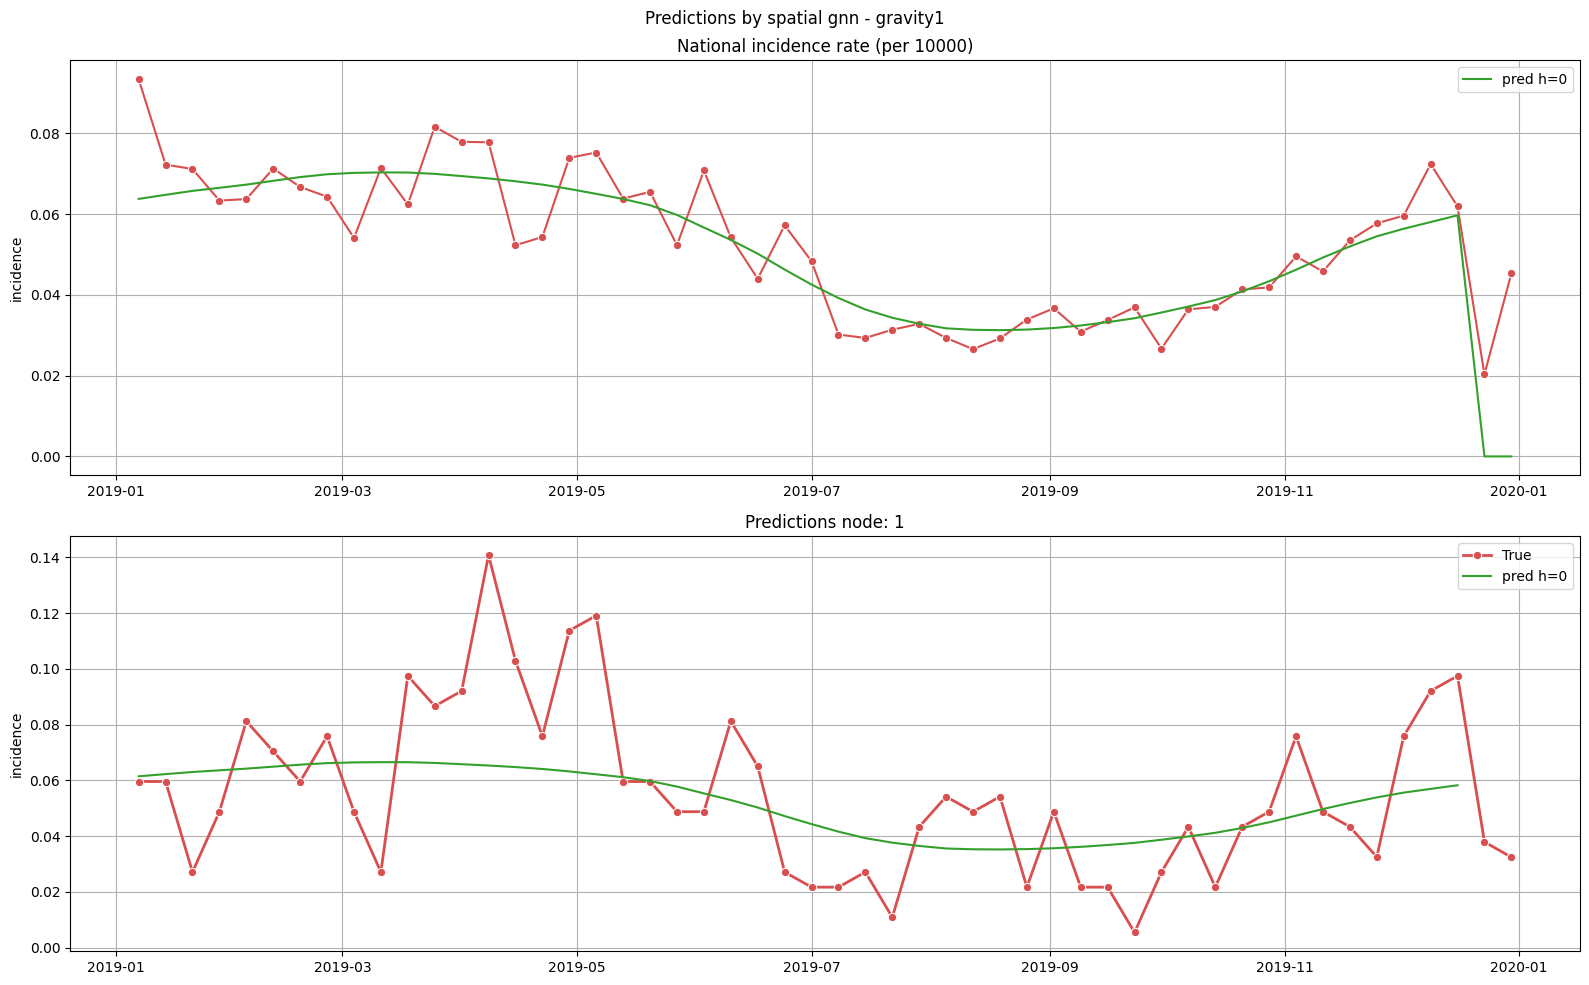

In [16]:
graphtype = 'gravity1'


dl1 = epidataloader.copy().retrieve_graph(graphtype).construct_dataloaders()

ml1      = SpatialGNNModel(dl1, name = f'spatial gnn - {graphtype}')
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
ml1.forecast('test')
ml1.show_forecasts('test')